[Home](../../README.md)

### Data Wrangling

This is a demonstration of data wrangling using [Pandas](https://pandas.pydata.org/) the library for data analysis and manipulation.

This Jupyter Notepad demonstrates different processes you can apply to your data to prepare it for feature engineering and model training. For this demonstration we will wrangle the diabetes data set you previewed in the last Jupyter Notebook.

> [!Note]
> None of these processes are destructive to the source CSV as long as you save the modified data to a new CSV.

#### Planning
Because of the nature of my data, I decided to do feature engineering before data wrangling, as personally I thought that having the tracks and other values as strings instead of being one hot encoded values will make it easier for me to understand what I'm doing.

For the features I am going to engineer, they are as such
- Manufacturer's average finish at track
- Manufacturer's average finish at track type
- Manufacturer's average start at track

(to see if they are doing well or not)
- Average finish at track
- Average start at track

After I engineer these features, I will one-hot encode the string variables into numerical values so the ML model can actually use them

#### Load the required dependencies

In [8]:
# Import frameworks
import pandas as pd

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [9]:
data_frame = pd.read_csv("NASCAR 2017-2024 Full Race  Points Data - Cup.csv")

#### Dropping the unneccessary columns



For this section I created a 'clean' dataframe with only the columns I needed to have in the final CSV file, being `track, track_type, manu`, with the new features that I engineer to be the next columns. My first attempt at doing this was quite messy, as I had left in the `fin` and `start` columns, which were specific to the individual drivers. This led to the dataset having tons of duplicates of the same track and manufacturer, which carried over to my feature engineering as when I put them in, there was lots of duplicate values which wouldn't be good for the model's training. 

In [10]:
clean_dataframe = data_frame.drop(columns=[
            "year", 
            "fin",
            "start",
            "car_num", 
            "driver", 
            "team_name", 
            "laps", 
            "laps_led",
            "status", 
            "points", 
            "stage_1", 
            "stage_2", 
            "stage_3_or_duel", 
            "stage_points"
        ]
    )

clean_dataframe = (
    clean_dataframe
    .sort_values(["track", "track_type", "manu"]) #sort it
    .drop(columns=["race_num"]) #then drop race num because i dont need it
    .drop_duplicates()
)


clean_dataframe.head()

,track,track_type,manu
83,Atlanta,intermediate,Chevrolet
82,Atlanta,intermediate,Ford
84,Atlanta,intermediate,Toyota
7392,Atlanta,superspeedway,Chevrolet
7398,Atlanta,superspeedway,Ford


#### Engineering features

Engineering the features wasn't particularly difficult, as it was just learning how to create one then duplicating and changing that for the rest. For all of my features, I simply just averaged them by grouping them to their needed category and averaging the start or finish position.

In [11]:
# Calculate averages and merge them back into the csv
manu_avg_fin_track = (
    data_frame.groupby(["manu", "track"], as_index=False)
    .agg(manu_avg_fin_track=("fin", "mean"))
    .sort_values(["manu", "track"])
)

manu_avg_fin_track_type = (
    data_frame.groupby(["manu", "track_type"], as_index=False)
    .agg(manu_avg_fin_track_type=("fin", "mean"))
    .sort_values(["manu", "track_type"])
)

manu_avg_start_track = (
    data_frame.groupby(["manu", "track"], as_index=False)
    .agg(manu_avg_start_track=("start", "mean"))
    .sort_values(["manu", "track"])
)

avg_fin_track = (
    data_frame.groupby(["track"], as_index=False)
    .agg(avg_fin_track=("fin", "mean"))
)

# merge it all into 1
feature_engineered = (
    clean_dataframe
    .merge(manu_avg_fin_track, on=["manu", "track"], how="left")
    .merge(manu_avg_fin_track_type, on=["manu", "track_type"], how="left")
    .merge(manu_avg_start_track, on=["manu", "track"], how="left")
    .merge(avg_fin_track, on=["track"], how="left")
)

# manufacturer delta at track (higher = above average)
feature_engineered["manu_track_delta"] = (
    feature_engineered["avg_fin_track"] - feature_engineered["manu_avg_fin_track"]
).round(4)

#### Scaling the data

In [12]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

features = [
    "manu_avg_fin_track",
    "manu_avg_fin_track_type",
    "manu_avg_start_track",
    "avg_fin_track",
    "manu_track_delta"
]

# capture pre-scale stats first
pre_min = feature_engineered[features].min()
pre_max = feature_engineered[features].max()

scaler = MinMaxScaler()
feature_engineered[features] = scaler.fit_transform(feature_engineered[features])

post_min = feature_engineered[features].min()
post_max = feature_engineered[features].max()

print(f"Pre-scale min:\n{pre_min}")
print(f"Pre-scale max:\n{pre_max}")
print(f"Scaler data_min_ (raw): {np.round(scaler.data_min_, 4)}")
print(f"Scaler data_max_ (raw): {np.round(scaler.data_max_, 4)}")
print(f"Post-scale min:\n{post_min}")
print(f"Post-scale max:\n{post_max}")

Pre-scale min:
manu_avg_fin_track         14.262295
manu_avg_fin_track_type    16.258883
manu_avg_start_track        9.642857
avg_fin_track              17.145940
manu_track_delta           -3.766700
dtype: float64
Pre-scale max:
manu_avg_fin_track         23.420290
manu_avg_fin_track_type    21.265388
manu_avg_start_track       24.693548
avg_fin_track              20.402010
manu_track_delta            4.866100
dtype: float64
Scaler data_min_ (raw): [14.2623 16.2589  9.6429 17.1459 -3.7667]
Scaler data_max_ (raw): [23.4203 21.2654 24.6935 20.402   4.8661]
Post-scale min:
manu_avg_fin_track         0.0
manu_avg_fin_track_type    0.0
manu_avg_start_track       0.0
avg_fin_track              0.0
manu_track_delta           0.0
dtype: float64
Post-scale max:
manu_avg_fin_track         1.0
manu_avg_fin_track_type    1.0
manu_avg_start_track       1.0
avg_fin_track              1.0
manu_track_delta           1.0
dtype: float64


#### One hot encoding
Since some variables were strings which ML models can't use, I had to one hot encode them, including the track, track type and manufacturer

In [13]:
encoded_data = pd.get_dummies(feature_engineered, columns=["track", "track_type", "manu"], dtype=int)
print(encoded_data.head())

   manu_avg_fin_track  manu_avg_fin_track_type  manu_avg_start_track  \
0            0.686035                 1.000000              0.812065   
1            0.461775                 0.575617              0.453855   
2            0.350739                 0.195298              0.589339   
3            0.686035                 0.488865              0.812065   
4            0.461775                 0.368444              0.453855   

   avg_fin_track  manu_track_delta  track_Atlanta  track_Auto Club  \
0       0.639869          0.283929              1                0   
1       0.639869          0.521835              1                0   
2       0.639869          0.639619              1                0   
3       0.639869          0.283929              1                0   
4       0.639869          0.521835              1                0   

   track_Bristol  track_Bristol Dirt  track_COTA  ...  track_Watkins Glen  \
0              0                   0           0  ...                

> [!important]
> You need to save the calculations for each dataset you scale for scaling new values for prediction. Use [2.1.2.data.records.md](2.1.2.data.records.md) to record this information.

#### Save the wrangled data to CSV

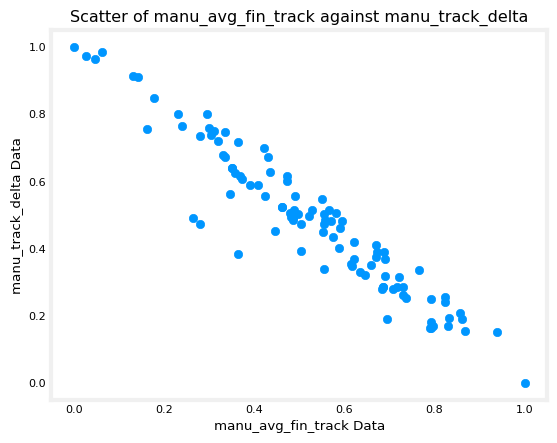

In [14]:
feature_engineered.to_csv(
    "../2.3.Model_Training/NASCAR data scaled (not encoded).csv", index=False, header=True
)
encoded_data.to_csv(
    "../2.3.Model_Training/NASCAR model ready.csv", index=False, header=True
)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("../../style_Matplotlib_charts.mplstyle")
# Scatter plot 2 columns to see the relationship
plt.scatter(
    feature_engineered["manu_avg_fin_track"],
    feature_engineered["manu_track_delta"],
)
plt.title(
    f"Scatter of {feature_engineered['manu_avg_fin_track'].name} against {feature_engineered['manu_track_delta'].name}"
)
plt.ylabel(f"{feature_engineered['manu_track_delta'].name} Data")
plt.xlabel(f"{feature_engineered['manu_avg_fin_track'].name} Data")
plt.show()